In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： database001
Windows
11
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
20
scpufreq(current=2400.0, min=0.0, max=2400.0)
svmem(total=16891371520, available=4897099776, percent=71.0, used=11994271744, free=4897099776)



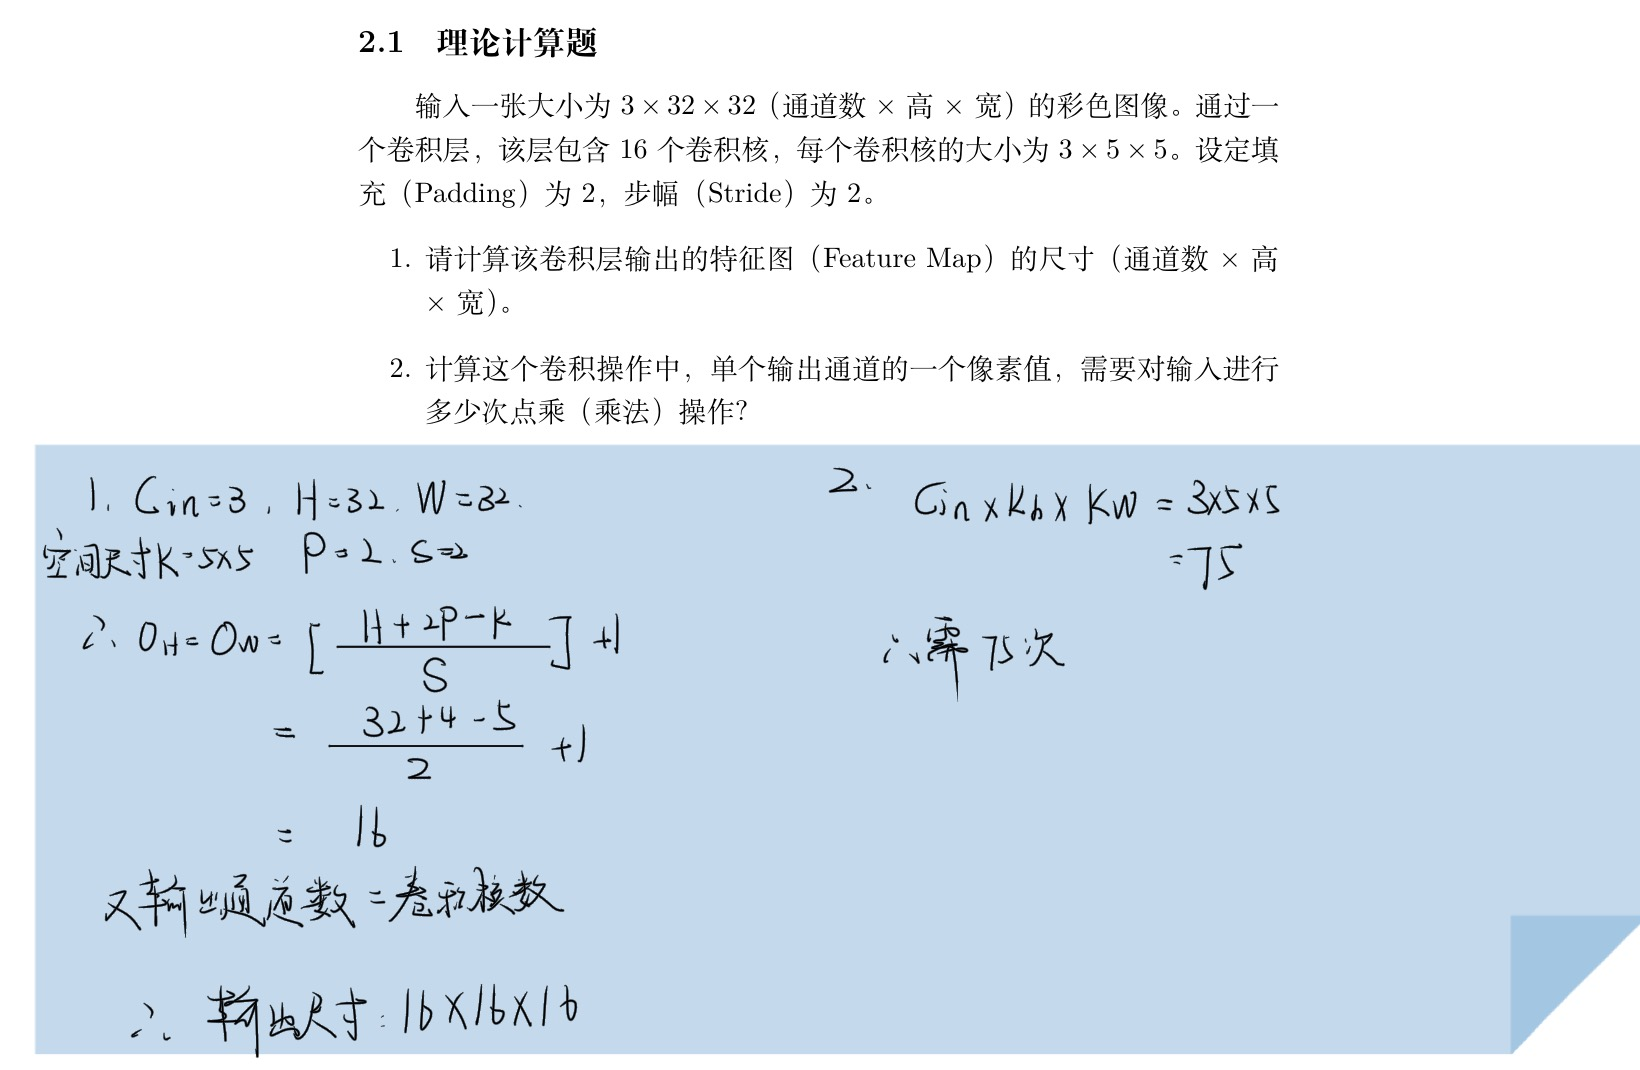

>  2.2 编程题

In [2]:
import numpy as np

def max_pool2d(x, kernel_size, stride=None, padding=0):
    """
    二维最大池化的前向传播

    参数:
        x           : np.ndarray, 形状 (N, C, H, W)
        kernel_size : int 或 (kh, kw)
        stride      : int 或 (sh, sw)，默认与 kernel_size 相同
        padding     : int 或 (ph, pw)，默认 0

    返回:
        out : np.ndarray, 形状 (N, C, H_out, W_out)
    """
    if stride is None:
        stride = kernel_size

    # ----- 参数统一为元组 -----
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(padding, int):
        padding = (padding, padding)

    kh, kw = kernel_size
    sh, sw = stride
    ph, pw = padding

    N, C, H, W = x.shape

    # 输出尺寸
    H_out = (H + 2 * ph - kh) // sh + 1
    W_out = (W + 2 * pw - kw) // sw + 1

    # 转为 float，以便使用 -inf 进行填充（避免影响 max 计算）
    x = x.astype(np.float64)

    # 对空间维度（H, W）进行常数填充，填充值为 -inf
    x_padded = np.pad(
        x,
        ((0, 0), (0, 0), (ph, ph), (pw, pw)),
        mode='constant',
        constant_values=-np.inf
    )

    out = np.zeros((N, C, H_out, W_out), dtype=x.dtype)

    # 滑动窗口，手动取最大值
    for i in range(H_out):
        for j in range(W_out):
            h_start = i * sh
            w_start = j * sw
            window = x_padded[:, :, h_start:h_start + kh, w_start:w_start + kw]
            out[:, :, i, j] = np.max(window, axis=(2, 3))

    return out

In [3]:
# 输入 (N=1, C=1, H=4, W=4)
x = np.arange(16, dtype=np.float64).reshape(1, 1, 4, 4)
print("输入:\n", x)

# 等价于 kernel_size=2, stride=2, padding=0 的最大池化
out = max_pool2d(x, kernel_size=2, stride=2, padding=0)
print("池化结果:\n", out)

输入:
 [[[[ 0.  1.  2.  3.]
   [ 4.  5.  6.  7.]
   [ 8.  9. 10. 11.]
   [12. 13. 14. 15.]]]]
池化结果:
 [[[[ 5.  7.]
   [13. 15.]]]]


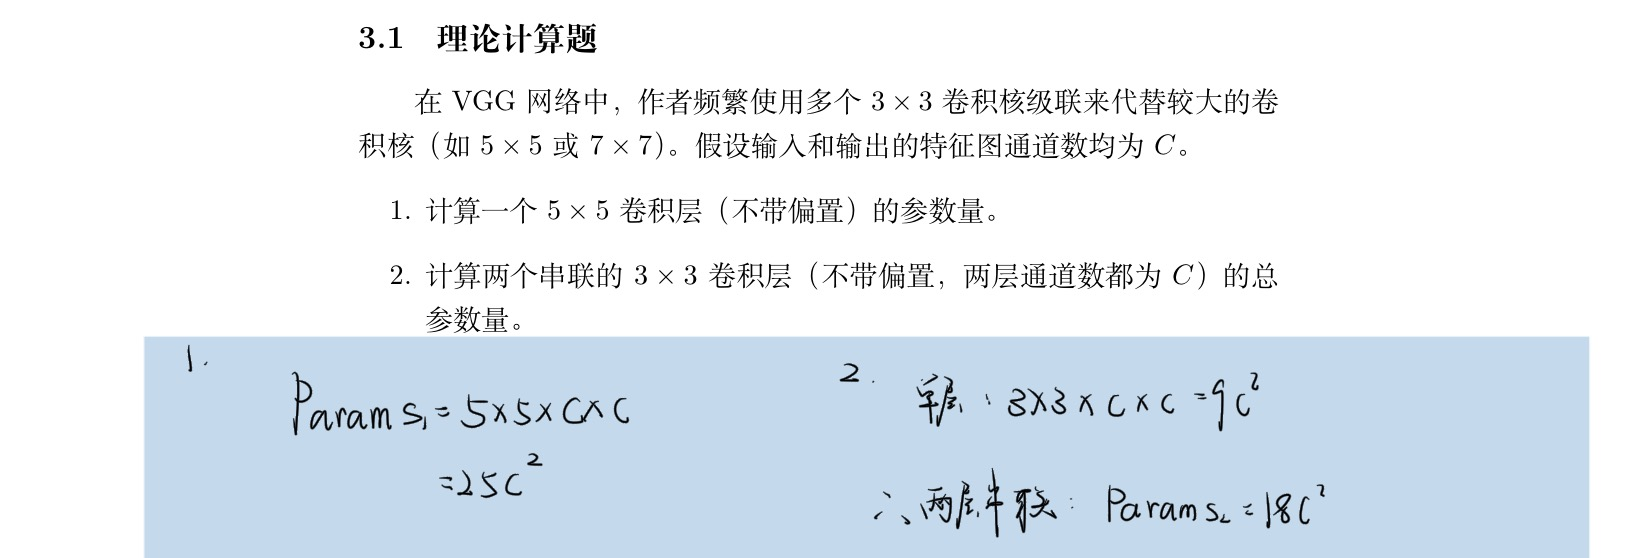

> 3.2 编程题

In [4]:
import torch.nn as nn

class NiNBlock(nn.Sequential):
    """
    Network in Network (NiN) 块。

    结构:
        Conv2d(in_channels, out_channels, kernel_size, stride, padding) + ReLU
        Conv2d(out_channels, out_channels, 1) + ReLU
        Conv2d(out_channels, out_channels, 1) + ReLU
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 1),
            nn.ReLU()
        )

In [5]:
import torch

# 创建一个 NiN 块：输入 3 通道，输出 64 通道，5x5 卷积，步幅 1，填充 2
nin_block = NiNBlock(in_channels=3, out_channels=64, kernel_size=5, stride=1, padding=2)

# 随机输入 (batch=4, C=3, H=32, W=32)
x = torch.randn(4, 3, 32, 32)
y = nin_block(x)

print(y.shape)  # torch.Size([4, 64, 32, 32])

torch.Size([4, 64, 32, 32])


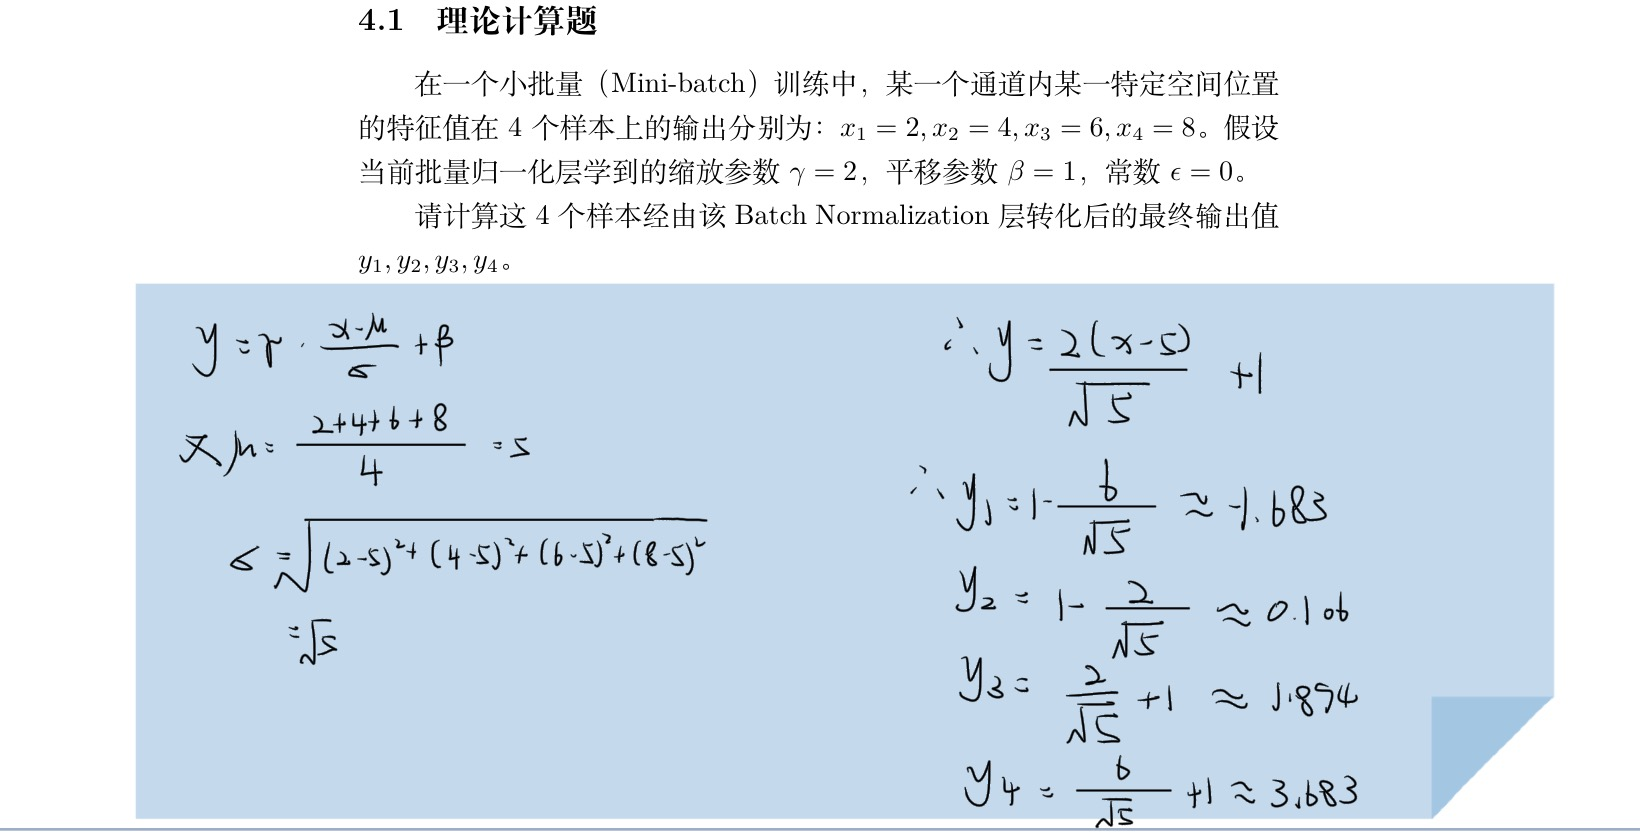

> 4.2 编程题

In [6]:
import torch.nn as nn

class Residual(nn.Module):
    """
    残差块（Residual block）。
    
    结构:
        - 卷积1: 3x3 Conv -> BatchNorm
        - 卷积2: 3x3 Conv -> BatchNorm
        - 跳跃连接:
            if use_1x1conv: 输入经过 1x1 Conv 调整通道与尺寸
            else:          恒等映射（要求 in_channels == out_channels 且 stride == 1）
        - 输出: 逐元素相加 f(x) + x

    参数:
        in_channels  : 输入通道数
        out_channels : 输出通道数（两个3x3卷积的通道数）
        stride       : 第一个3x3卷积的步幅，用于控制下采样（默认 1）
        use_1x1conv  : 是否使用 1x1 卷积调整跳跃连接的通道/尺寸（默认 False）
    """
    def __init__(self, in_channels, out_channels, stride=1, use_1x1conv=False):
        super().__init__()
        # 第一个 3x3 卷积 + BN
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 第二个 3x3 卷积 + BN
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1 卷积跳跃连接
        self.use_1x1conv = use_1x1conv
        if use_1x1conv:
            self.skip_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                       stride=stride, bias=False)
        else:
            self.skip_conv = None

    def forward(self, x):
        # 主路径：conv1 -> bn1 -> conv2 -> bn2
        out = self.bn1(self.conv1(x))
        out = self.bn2(self.conv2(out))

        # 跳跃连接
        identity = self.skip_conv(x) if self.use_1x1conv else x

        # 残差相加
        out += identity
        return out

In [7]:
import torch

# 情况 1：输入输出通道相同，无需 1x1 卷积
res_block1 = Residual(in_channels=64, out_channels=64, stride=1, use_1x1conv=False)
x = torch.randn(2, 64, 32, 32)
print(res_block1(x).shape)   # torch.Size([2, 64, 32, 32])

# 情况 2：通道数变化或 stride=2，需使用 1x1 卷积对齐形状
res_block2 = Residual(in_channels=64, out_channels=128, stride=2, use_1x1conv=True)
x = torch.randn(2, 64, 32, 32)
print(res_block2(x).shape)   # torch.Size([2, 128, 16, 16])

torch.Size([2, 64, 32, 32])
torch.Size([2, 128, 16, 16])


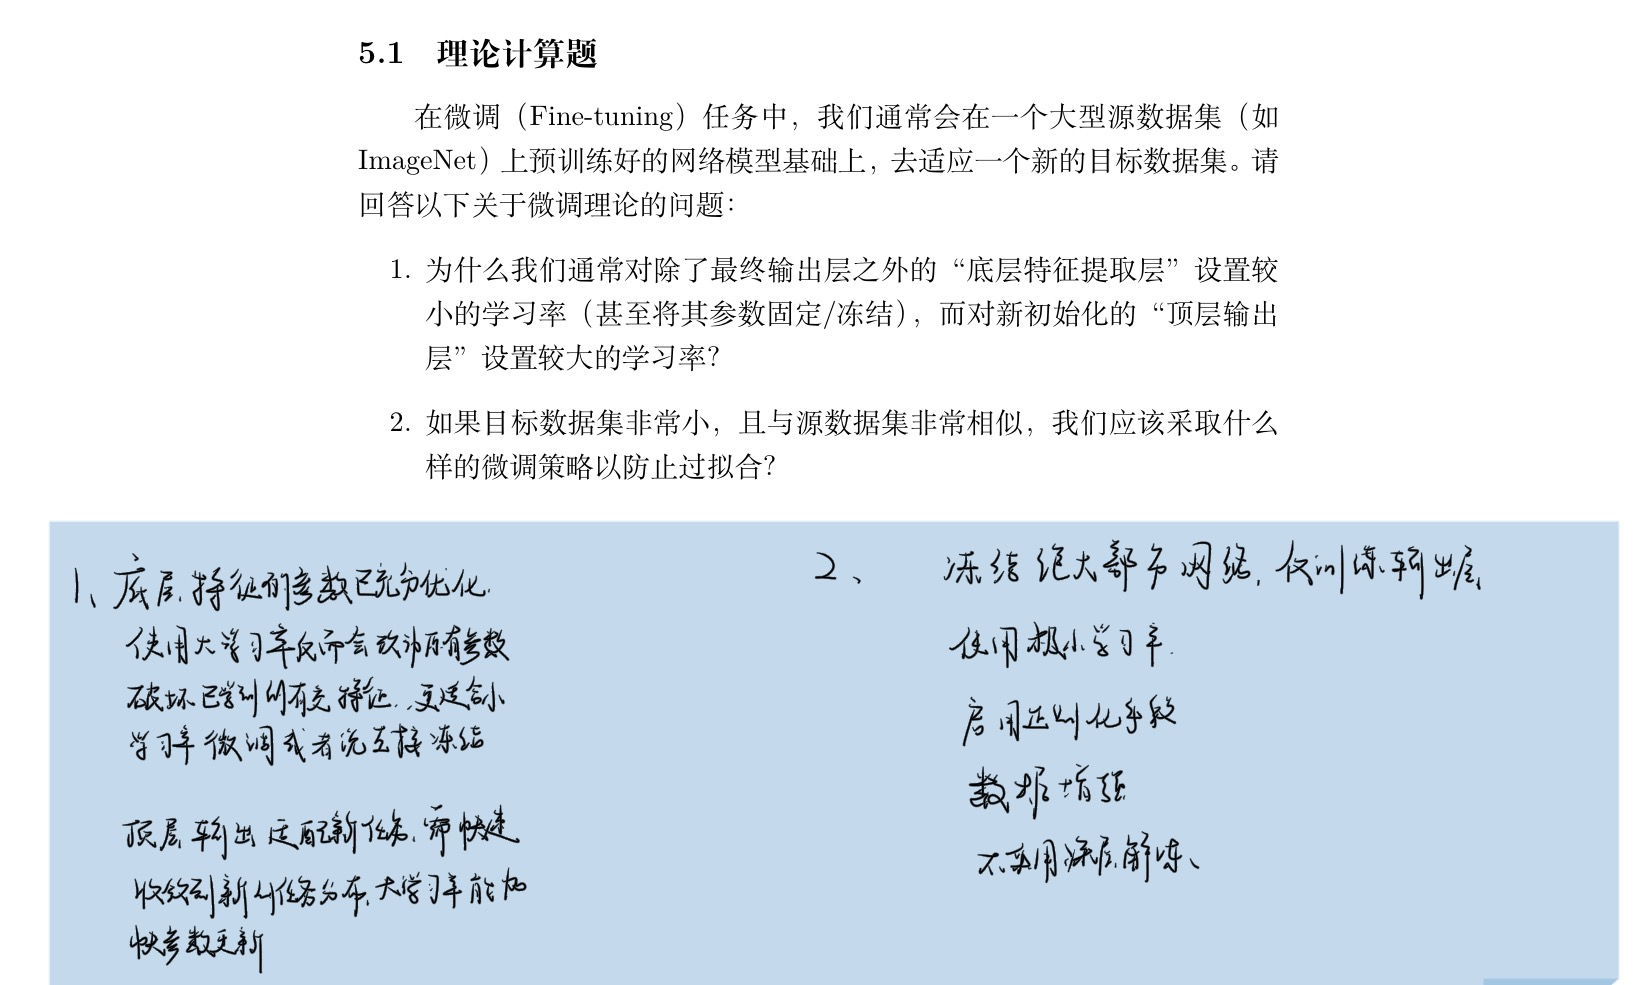

> 5.2 编程题

In [8]:
import PIL
print(PIL.__version__)

12.2.0


In [9]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [10]:
from torchvision import transforms
from PIL import Image
%matplotlib inline
import matplotlib.pyplot as plt

aug_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0),
    transforms.ToTensor()
])

# 加载图片并应用增广
img = Image.open(r"D:/学习/深度学习/q.jpg")
aug_img = aug_pipeline(img)



In [11]:
# 输出并显示
import matplotlib.pyplot as plt
print("Tensor shape:", aug_img.shape)
print("Value range: [{:.3f}, {:.3f}]".format(aug_img.min(), aug_img.max()))



Tensor shape: torch.Size([3, 224, 224])
Value range: [0.000, 1.000]


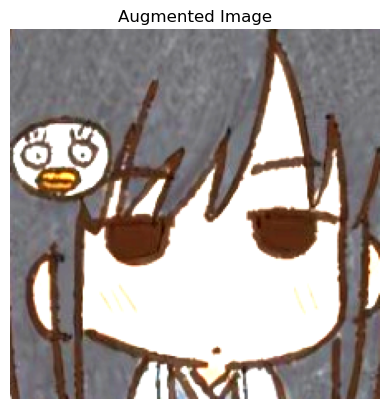

In [12]:
plt.imshow(transforms.ToPILImage()(aug_img))
plt.title("Augmented Image")
plt.axis('off')
plt.show()

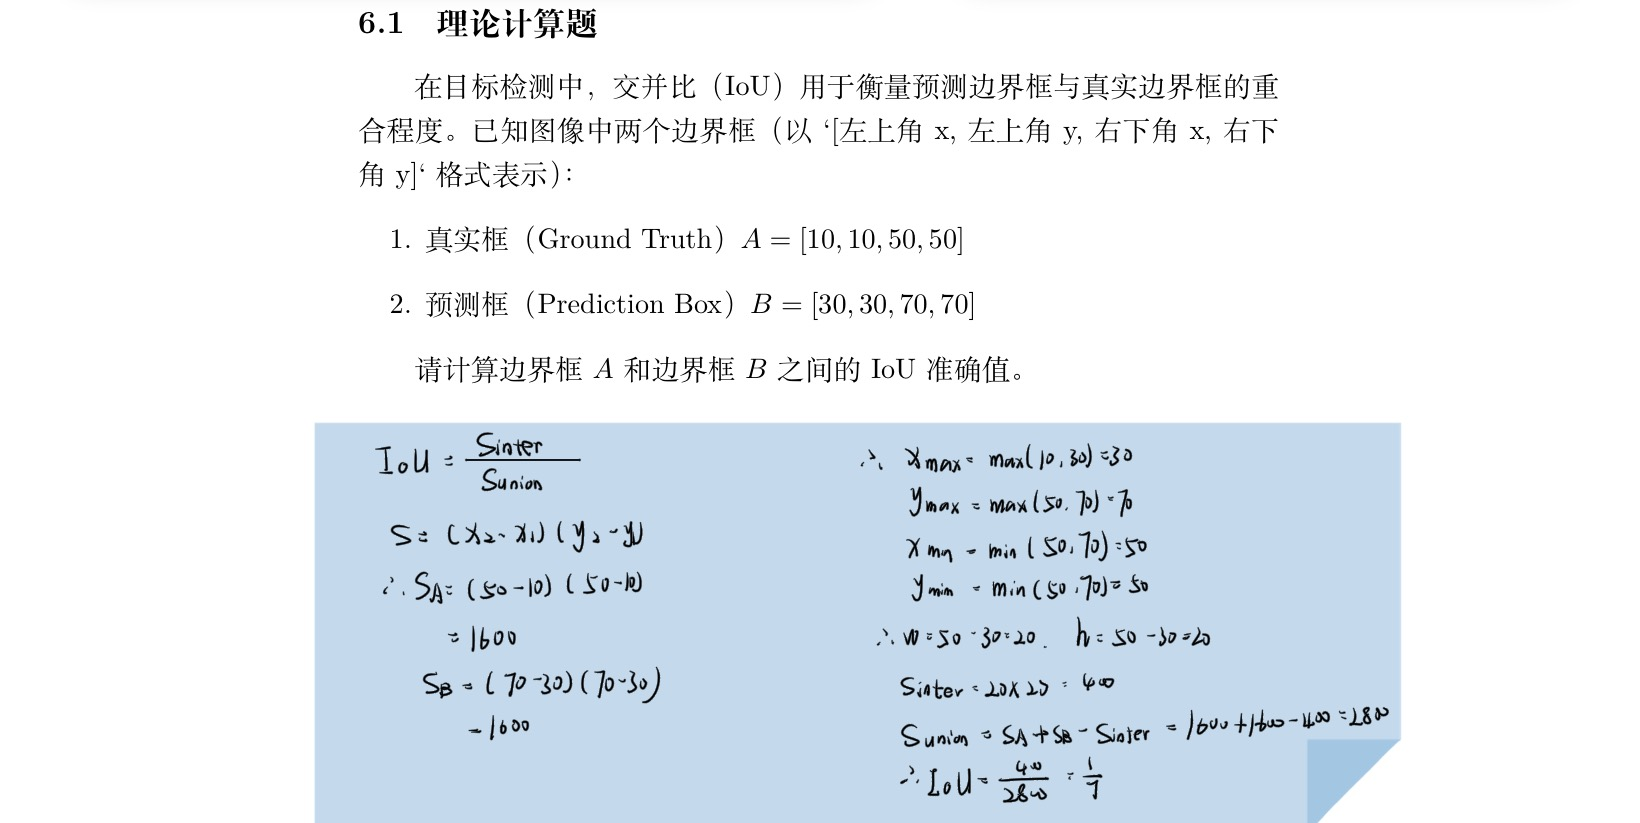

> 6.2 编程题

In [13]:
import torch
import torch.nn.functional as F

def label_smoothing_cross_entropy(pred, target, epsilon=0.1, reduction='mean'):
    """
    计算标签平滑后的交叉熵损失。

    参数:
        pred (Tensor) : 模型预测的 logits，形状 (N, K)，未经过 softmax
        target (Tensor): 真实类别索引，形状 (N,)，每个元素为 [0, K-1] 的整数
        epsilon (float): 平滑因子，默认 0.1
        reduction (str): 'mean' 或 'sum'，默认 'mean'

    返回:
        loss (Tensor): 标量损失值
    """
    N, K = pred.shape
    # 计算 log_softmax，数值更稳定
    log_probs = F.log_softmax(pred, dim=1)   # (N, K)

    # 创建平滑后的标签分布
    with torch.no_grad():
        # 首先全部填充 epsilon / (K - 1)
        smooth_labels = torch.full((N, K), epsilon / (K - 1), device=pred.device)
        # 在真实类位置填入 1 - epsilon
        smooth_labels.scatter_(1, target.unsqueeze(1), 1.0 - epsilon)

    # 逐样本交叉熵: - sum(y_true * log_prob)
    loss_per_sample = - (smooth_labels * log_probs).sum(dim=1)  # (N,)

    if reduction == 'mean':
        return loss_per_sample.mean()
    elif reduction == 'sum':
        return loss_per_sample.sum()
    else:
        return loss_per_sample

In [14]:
# 假设 3 分类问题，batch_size=4
logits = torch.randn(4, 3)
targets = torch.tensor([0, 2, 1, 0])

loss = label_smoothing_cross_entropy(logits, targets, epsilon=0.1)
print(loss)   # 输出平滑后的交叉熵标量

tensor(1.4500)
